In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

In [ ]:
model = CmdStanModel(stan_file='trape4.stan')
fit = model.sample(data='trape_individuals.json', show_console=False, show_progress=True, thin=10, iter_sampling=10000, chains=4, parallel_chains=4)

print(fit.summary())

draws = fit.draws_pd()
draws.to_csv('trape4_draws.csv')
with open('trape4_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

14:22:08 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:39:42 - cmdstanpy - INFO - CmdStan done processing.
14:39:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape4.stan', line 84, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape4.stan', line 84, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape4.stan', line 84, column 16 to column 98)
	Exception: exponential_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'trape4.stan', line 73, column 4 to column 42)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'trape4.stan', line 76, column 4 to column 88)
	Exception: poisson_lpmf: Rate parameter is -1.98888e-14, but must be nonnegative! (in 'trape4.stan', line 84, column 16 to column 98)
	Exception: poisson_lpmf: Rate parameter is -7.97079e-15, but must be nonnegative! (in 'trape4.stan',


                                 Mean      MCSE     StdDev           5%  \
lp__                      7490.570000  0.848520  31.506600  7444.720000   
lambda_tau_elp               1.793960  0.003799   0.237687     1.428330   
mu_delta_clinical_raw        3.411940  0.002794   0.167738     3.143730   
sigma_delta_clinical_raw     0.826999  0.005366   0.215813     0.475010   
tau_elp[1]                   0.402220  0.004091   0.253348     0.059512   
...                               ...       ...        ...          ...   
log_lik[634]                -2.094410  0.011501   0.714053    -3.619050   
log_lik[635]                -1.192000  0.003918   0.242715    -1.704020   
log_lik[636]                -0.290573  0.004147   0.265216    -0.805315   
log_lik[637]                -0.084090  0.001728   0.110277    -0.282142   
log_lik[638]                -0.010628  0.000456   0.028914    -0.040731   

                                  50%          95%    N_Eff  N_Eff/s     R_hat  
lp__             

In [2]:
with open('trape4_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

In [3]:
z = az.from_cmdstanpy(fit)
z

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [5]:
i = 1 # index of individual to extract: 1 to 111
vars = ['mu_delta_clinical_raw', 'sigma_delta_clinical_raw', 'lambda_tau_elp', 'lambda', 'tau_elp', 'delta_clinical', 'rho_clinical', 'gamma_clinical']
y = z.posterior.isel(lambda_dim_0=i, tau_elp_dim_0=i, delta_clinical_dim_0=i, rho_clinical_dim_0=i, gamma_clinical_dim_0=i)

Rhat values good

In [6]:
print(az.rhat(y, var_names=vars))

<xarray.Dataset> Size: 104B
Dimensions:                   ()
Coordinates:
    tau_elp_dim_0             int64 8B 1
    rho_clinical_dim_0        int64 8B 1
    lambda_dim_0              int64 8B 1
    delta_clinical_dim_0      int64 8B 1
    gamma_clinical_dim_0      int64 8B 1
Data variables:
    mu_delta_clinical_raw     float64 8B 1.001
    sigma_delta_clinical_raw  float64 8B 1.003
    lambda_tau_elp            float64 8B 1.0
    lambda                    float64 8B 1.001
    tau_elp                   float64 8B 1.001
    delta_clinical            float64 8B 1.0
    rho_clinical              float64 8B 1.0
    gamma_clinical            float64 8B 1.0


Effective samples sizes good

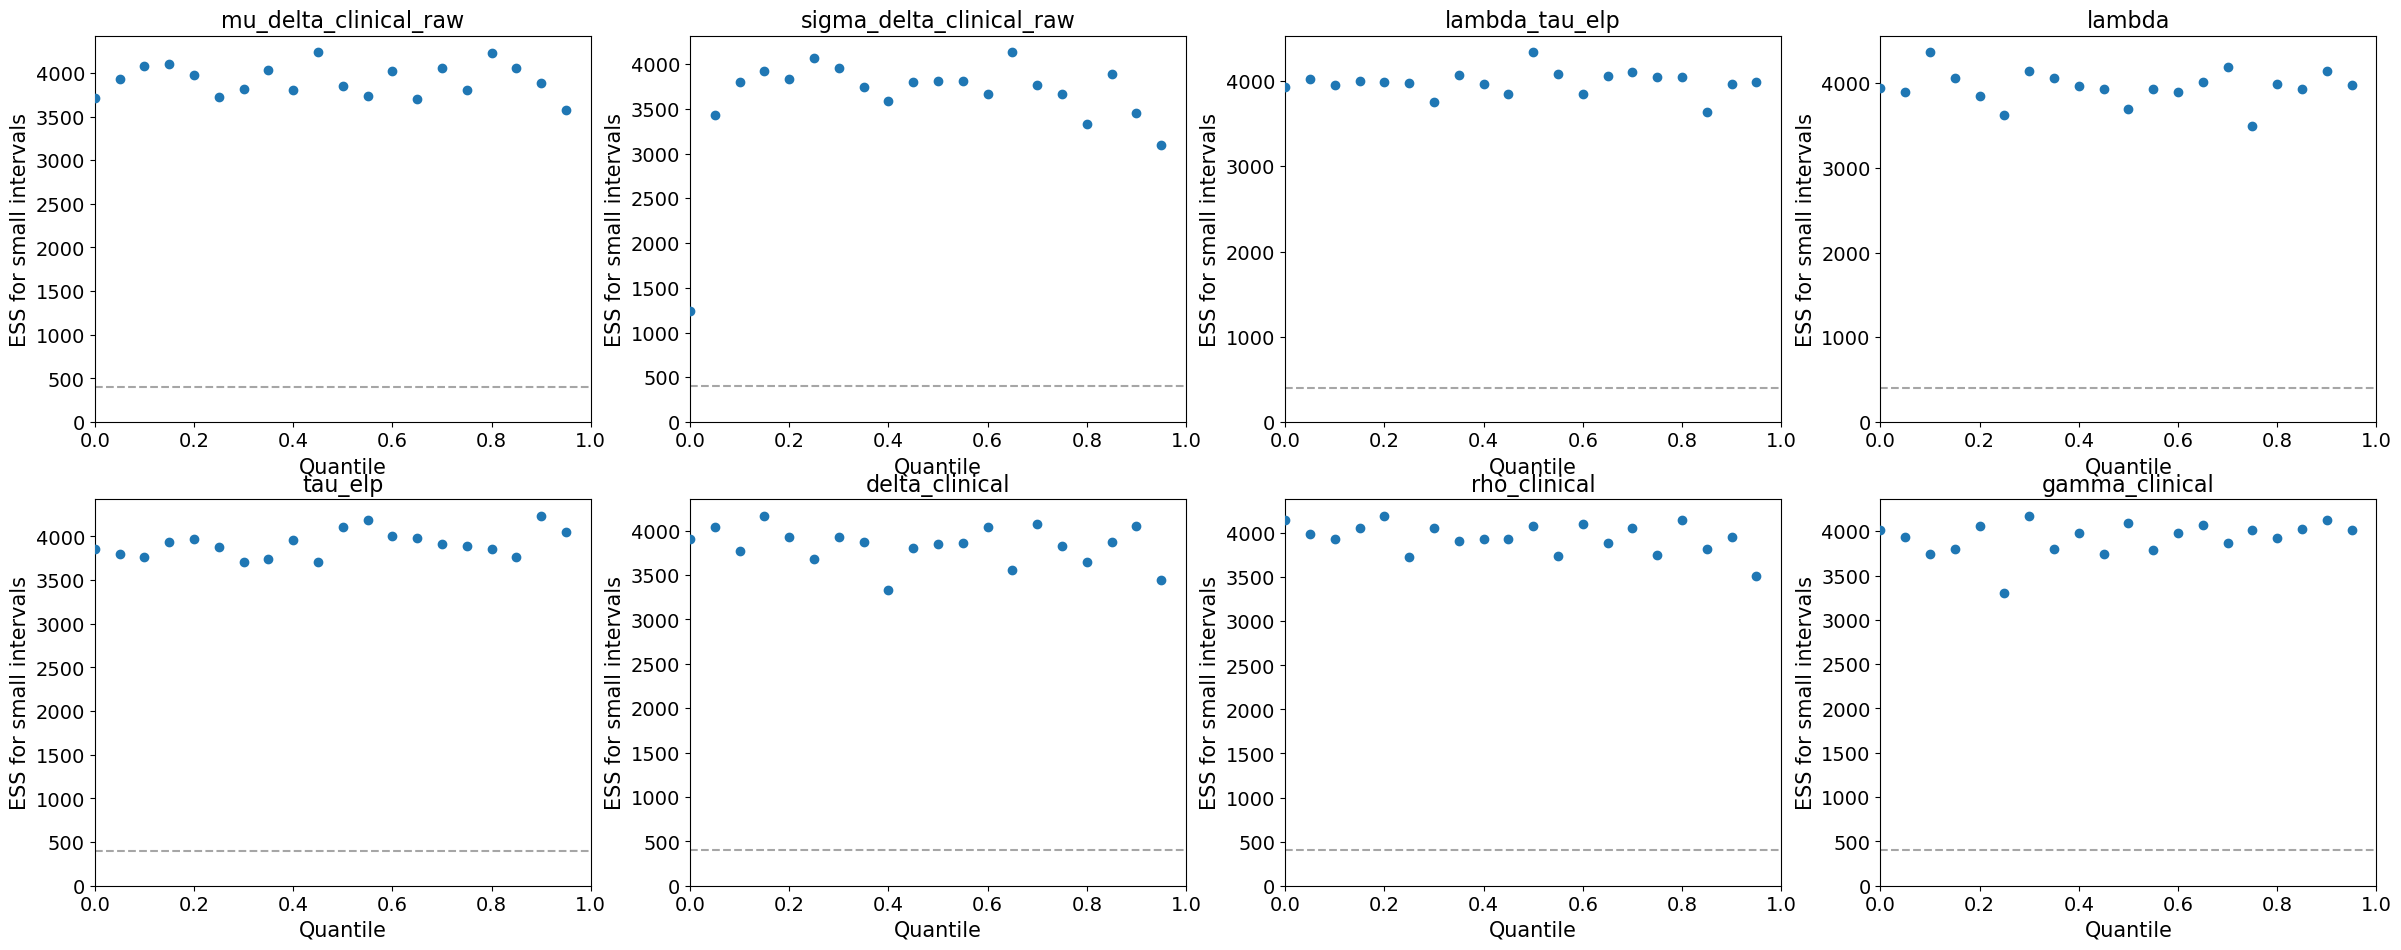

In [7]:
az.plot_ess(y, var_names=vars);

No major autocorrelation

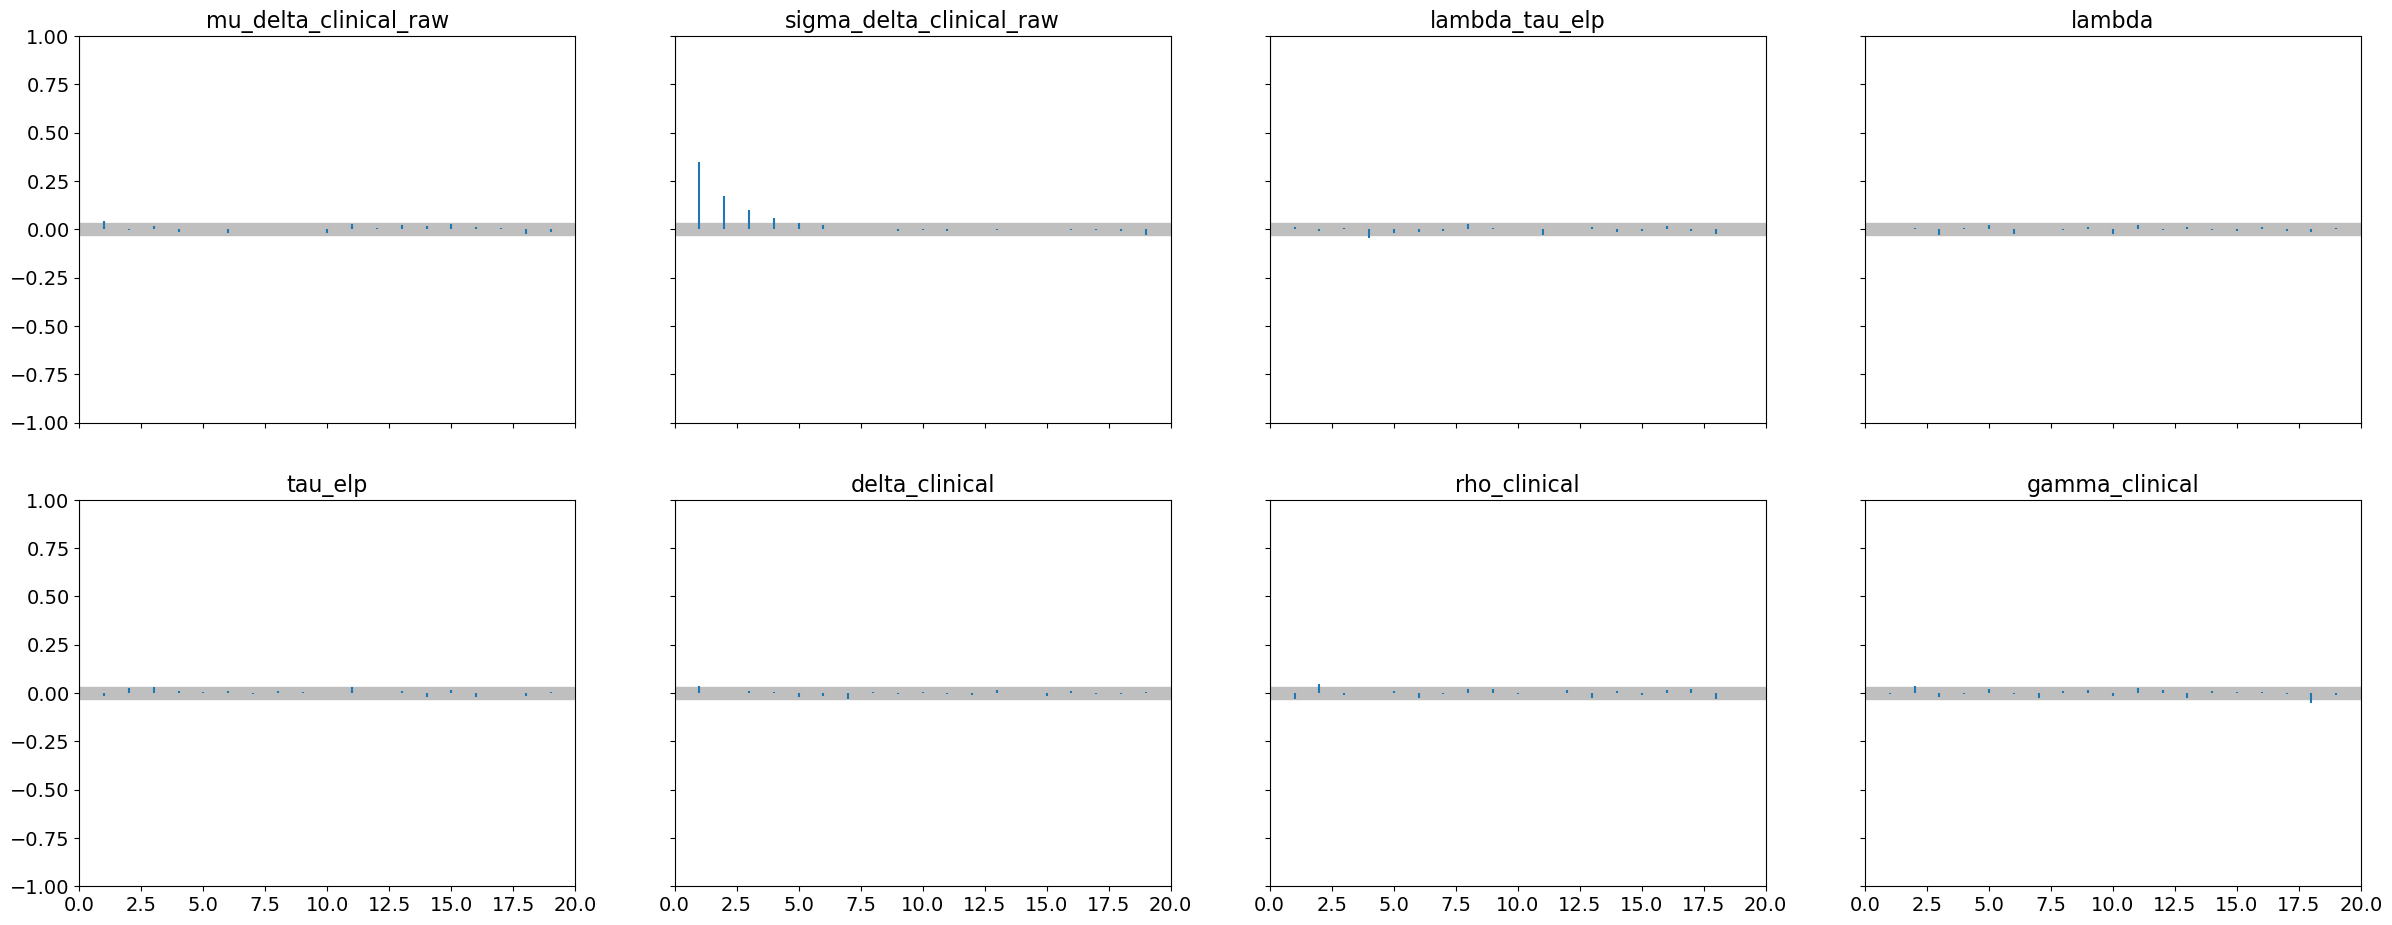

In [8]:
az.plot_autocorr(y, var_names=vars, combined=True, max_lag=20,);

Chains look good

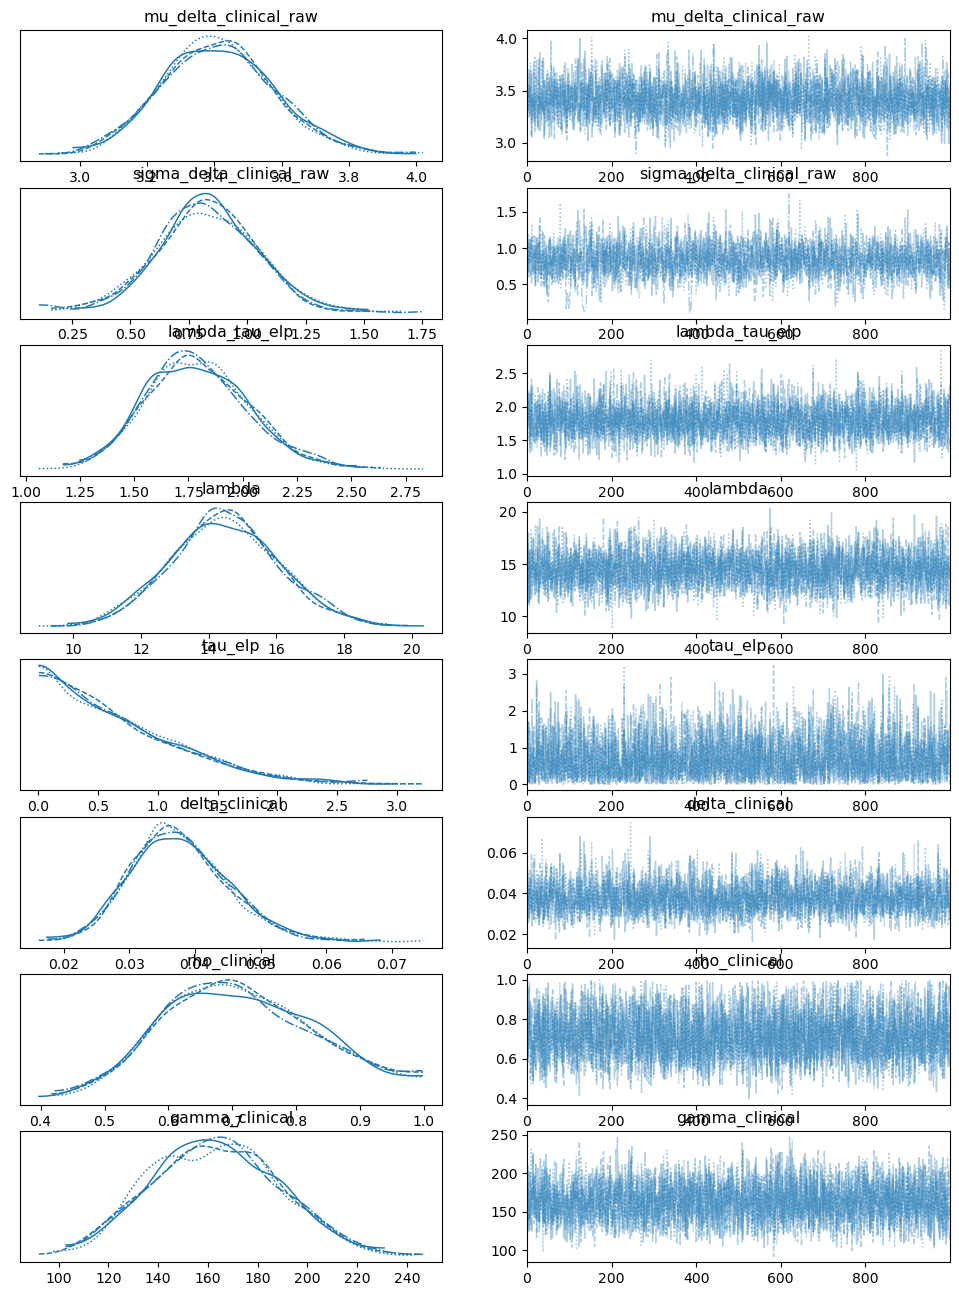

In [9]:
az.plot_trace(y, var_names=vars);

Pair plot reveals identifiability issue between rho and gamma

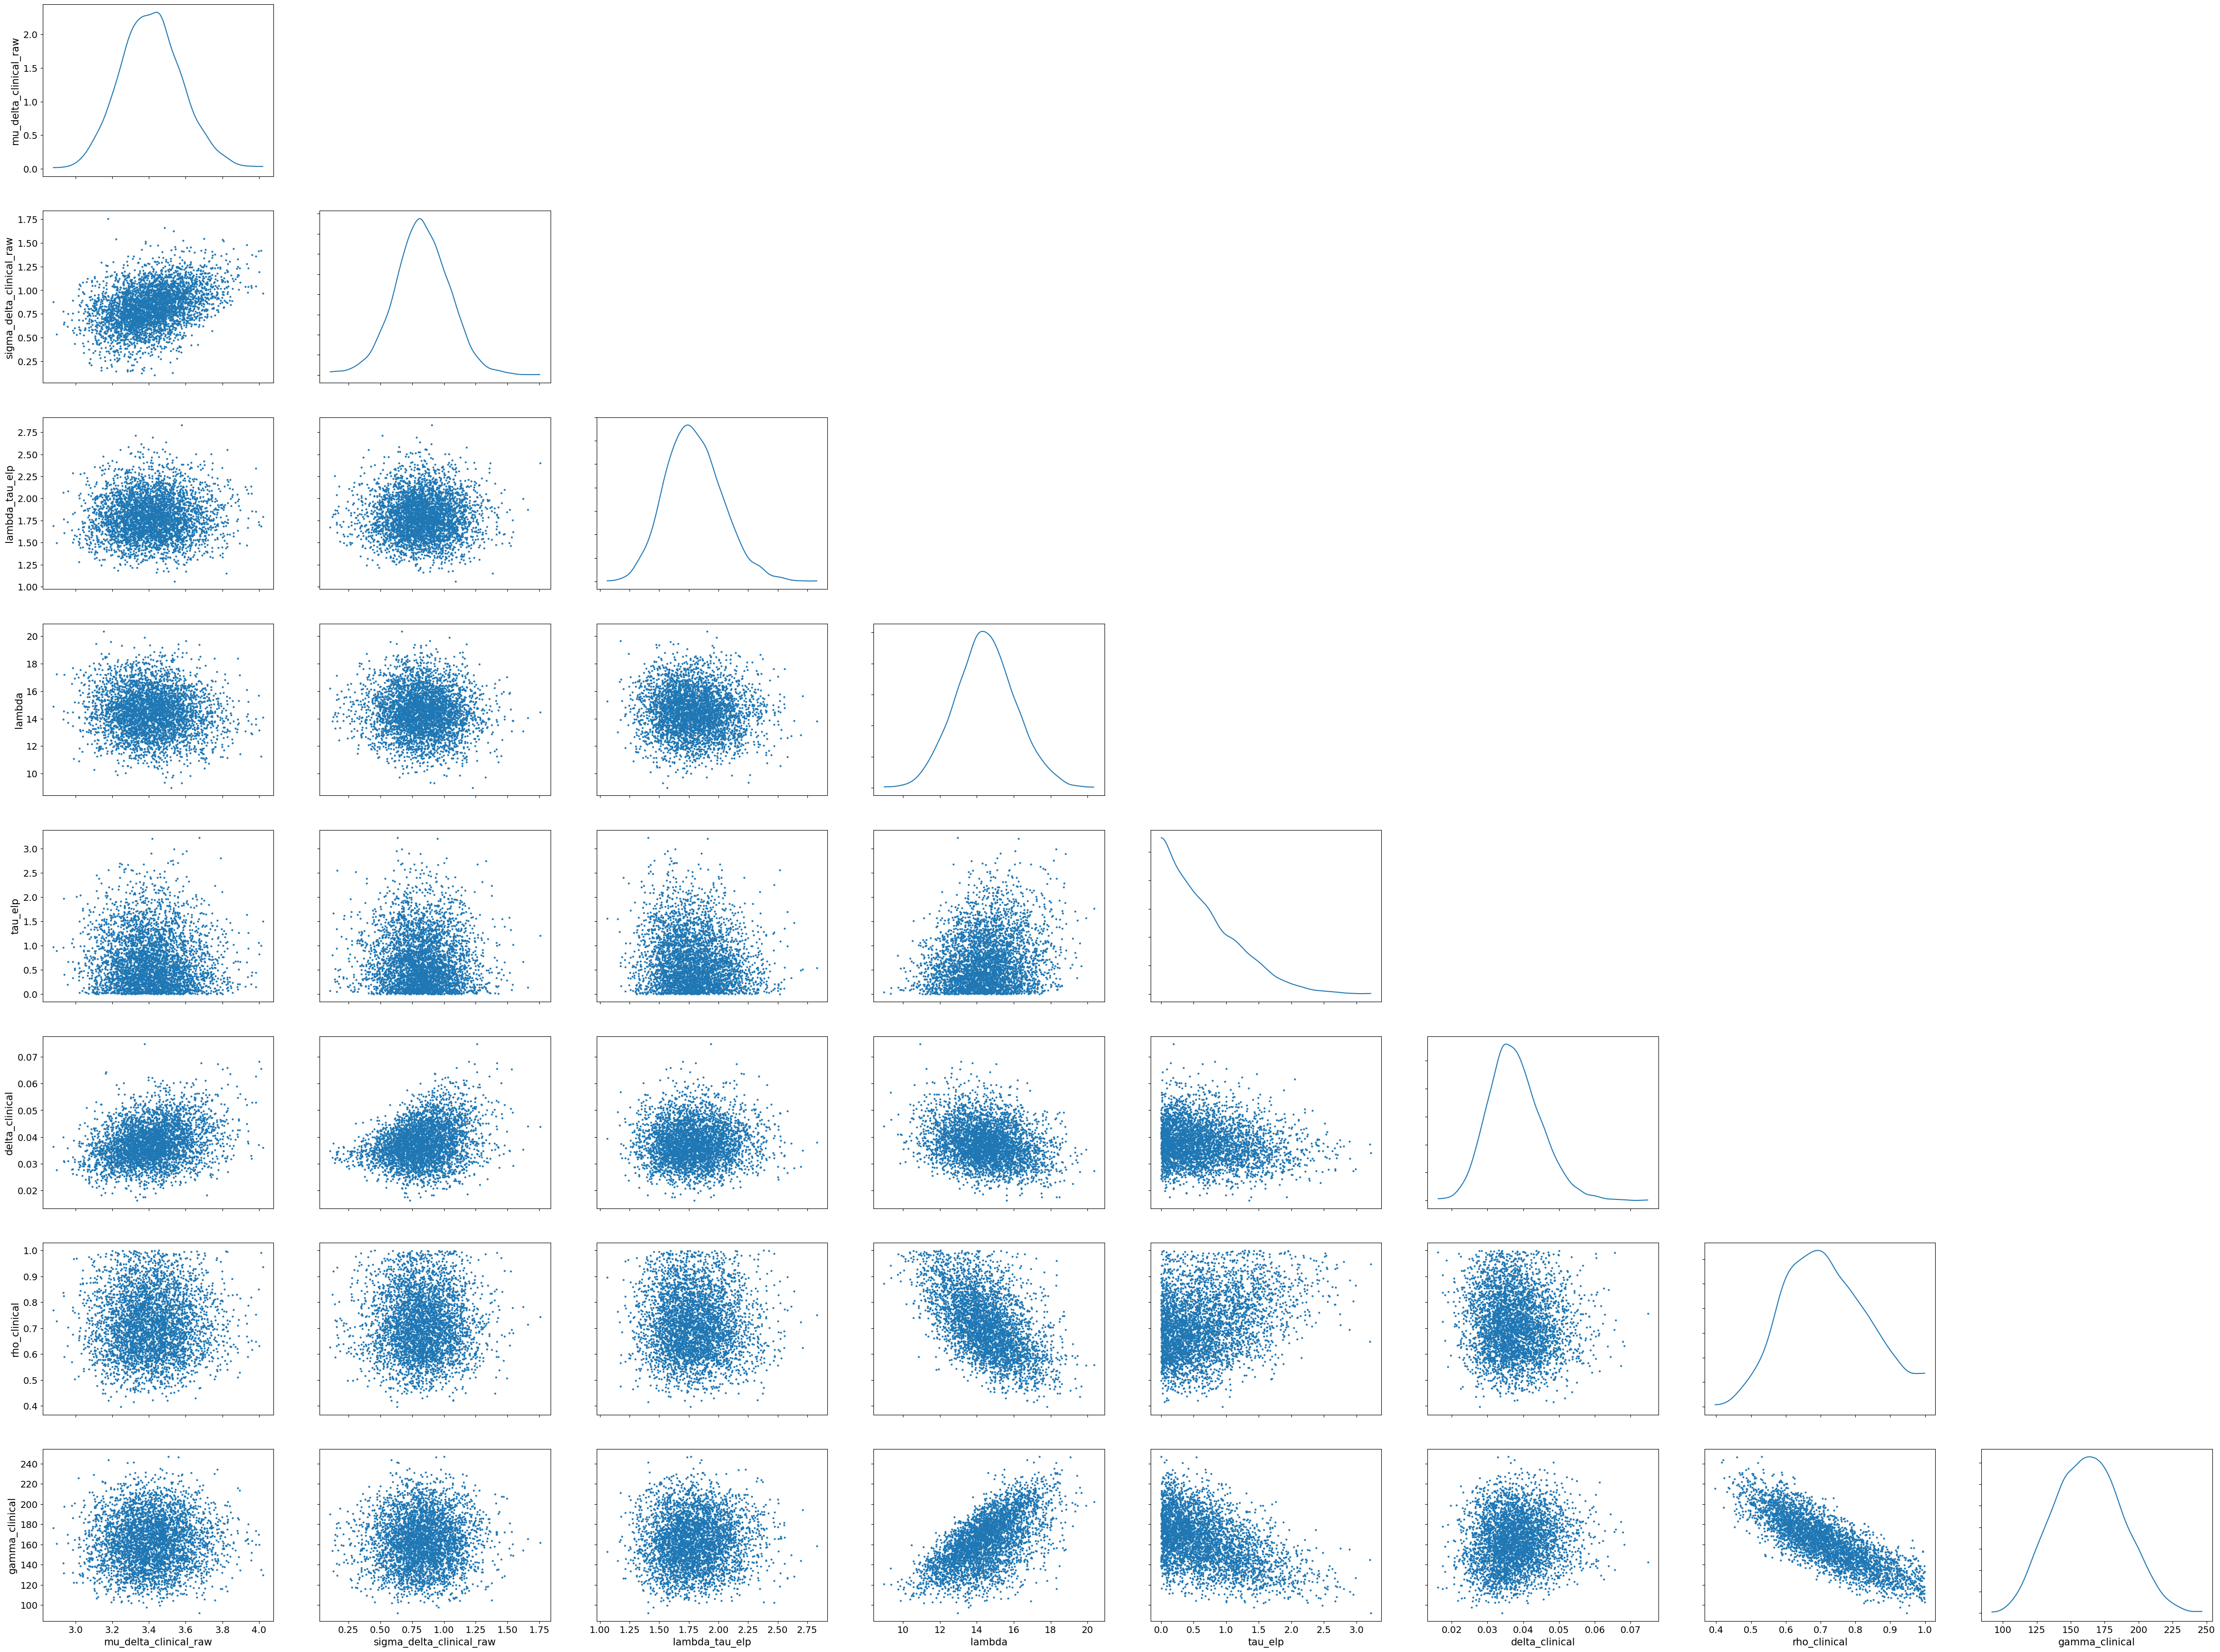

In [10]:
az.plot_pair(y, var_names=vars, marginals=True);